In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
confusion_matrix, roc_auc_score, roc_curve)
import seaborn as sns
print("Libraries imported!")

Libraries imported!


In [2]:
df = pd.read_csv('cleaned_data.csv')
X_raw = df['clean_text'].astype(str).values
y = df['label'].values
MAX_WORDS = 10000
MAX_LEN = 300
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_raw)
sequences = tokenizer.texts_to_sequences(X_raw)
X_pad = pad_sequences(sequences, maxlen=MAX_LEN, truncating='post')
X_train, X_test, y_train, y_test = train_test_split(
X_pad, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (35378, 300), Test: (8845, 300)


In [3]:
model = Sequential([
Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
LSTM(64, return_sequences=True),
Dropout(0.3),
LSTM(32),
Dropout(0.3),
Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
es = EarlyStopping(monitor='val_loss',
patience=3,
restore_best_weights=True)
history = model.fit(
X_train, y_train,
epochs=10,
batch_size=64,
validation_split=0.1,
callbacks=[es],
verbose=1
)
print("Training complete!")

Epoch 1/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 147s 284ms/step - accuracy: 0.9088 - loss: 0.2491 - val_accuracy: 0.6521 - val_loss: 0.6276
Epoch 2/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 151s 302ms/step - accuracy: 0.8783 - loss: 0.3258 - val_accuracy: 0.8118 - val_loss: 0.4042
Epoch 3/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 242s 382ms/step - accuracy: 0.9676 - loss: 0.1119 - val_accuracy: 0.9661 - val_loss: 0.1019
Epoch 4/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 320s 644ms/step - accuracy: 0.9721 - loss: 0.0912 - val_accuracy: 0.9633 - val_loss: 0.1010
Epoch 5/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 162s 325ms/step - accuracy: 0.9127 - loss: 0.2387 - val_accuracy: 0.9302 - val_loss: 0.1855
Epoch 6/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 152s 305ms/step - accuracy: 0.9465 - loss: 0.1473 - val_accuracy: 0.9494 - val_loss: 0.1226
Epoch 7/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 188s 277ms/step - accuracy: 0.9546 - loss: 0.1264 - val_accuracy: 0.9601 - val_loss: 0.1049
Training complete!


In [5]:
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"LSTM Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC : {roc_auc:.4f}")
print(classification_report(y_test, y_pred,
target_names=['Fake','Real']))

277/277 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step
LSTM Accuracy : 0.9630 (96.30%)
ROC-AUC : 0.9944
              precision    recall  f1-score   support

        Fake       0.99      0.94      0.96      4562
        Real       0.94      0.99      0.96      4283

    accuracy                           0.96      8845
   macro avg       0.96      0.96      0.96      8845
weighted avg       0.96      0.96      0.96      8845



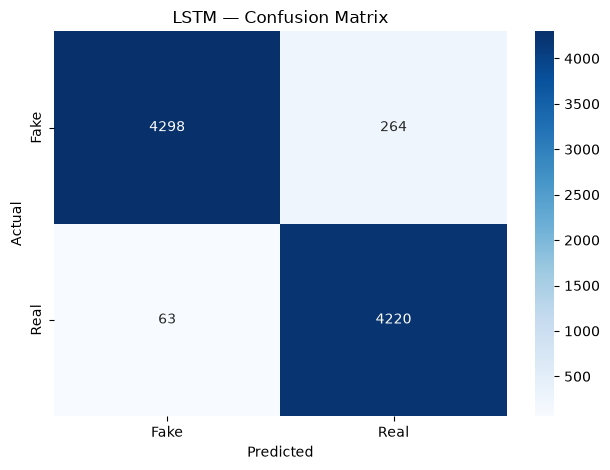

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Fake','Real'],
yticklabels=['Fake','Real'])
plt.title('LSTM — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

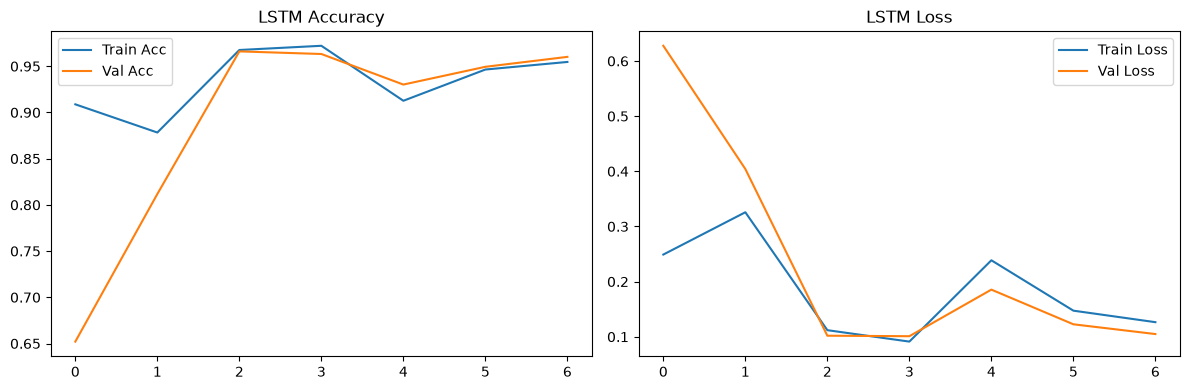

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'],label='Val Acc')
plt.title('LSTM Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('LSTM Loss'); plt.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

In [8]:
os.makedirs('saved_models', exist_ok=True)
model.save('saved_models/lstm_model.h5')
pickle.dump(tokenizer,
open('saved_models/lstm_tokenizer.pkl','wb'))
print("LSTM model and tokenizer saved!")

LSTM model and tokenizer saved!
